In [6]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

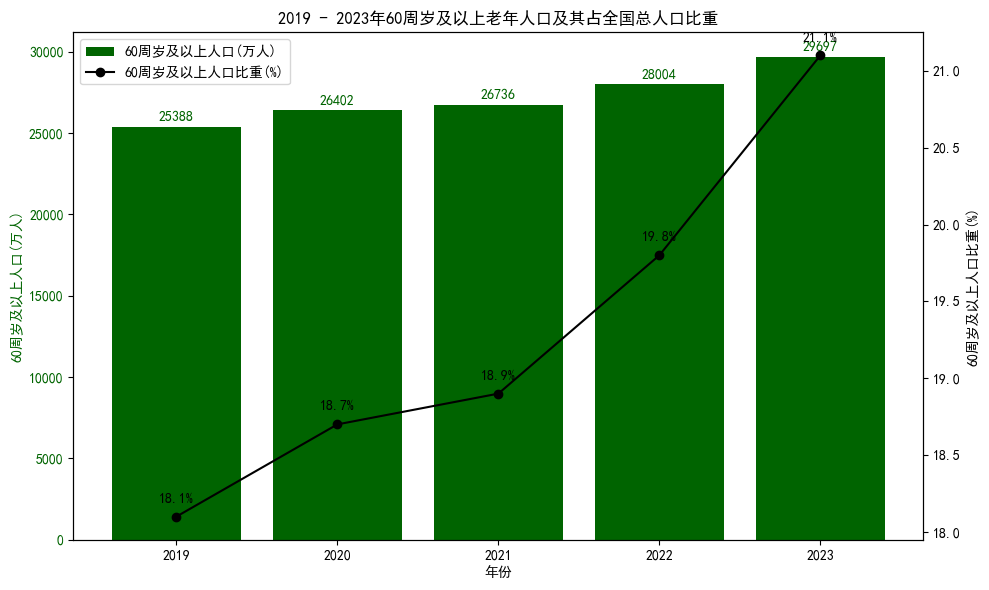

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = np.array([2019, 2020, 2021, 2022, 2023])
# 60周岁及以上人口（万人）
elderly_population = np.array([25388, 26402, 26736, 28004, 29697])
# 60周岁及以上人口比重（%）
proportion = np.array([18.1, 18.7, 18.9, 19.8, 21.1])

# 创建画布和轴
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制柱状图（左轴）
bars = ax1.bar(years, elderly_population, color='darkgreen', label='60周岁及以上人口(万人)')
ax1.set_xlabel('年份')
ax1.set_ylabel('60周岁及以上人口(万人)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')

# 在柱状图上方添加数据标签
for bar, pop in zip(bars, elderly_population):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'{pop}', ha='center', va='bottom', color='darkgreen')

# 创建右轴用于绘制折线图
ax2 = ax1.twinx()
line, = ax2.plot(years, proportion, marker='o', color='black', label='60周岁及以上人口比重(%)')
ax2.set_ylabel('60周岁及以上人口比重(%)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# 在折线图数据点旁边添加数据标签
for x, y in zip(years, proportion):
    ax2.annotate(f'{y}%', (x, y), textcoords='offset points',
                 xytext=(0,10), ha='center', color='black')

# 添加图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# 设置x轴刻度为年份
ax1.set_xticks(years)

# 展示图表
plt.title('2019 - 2023年60周岁及以上老年人口及其占全国总人口比重')
plt.tight_layout()  # 调整布局避免内容重叠
plt.show()

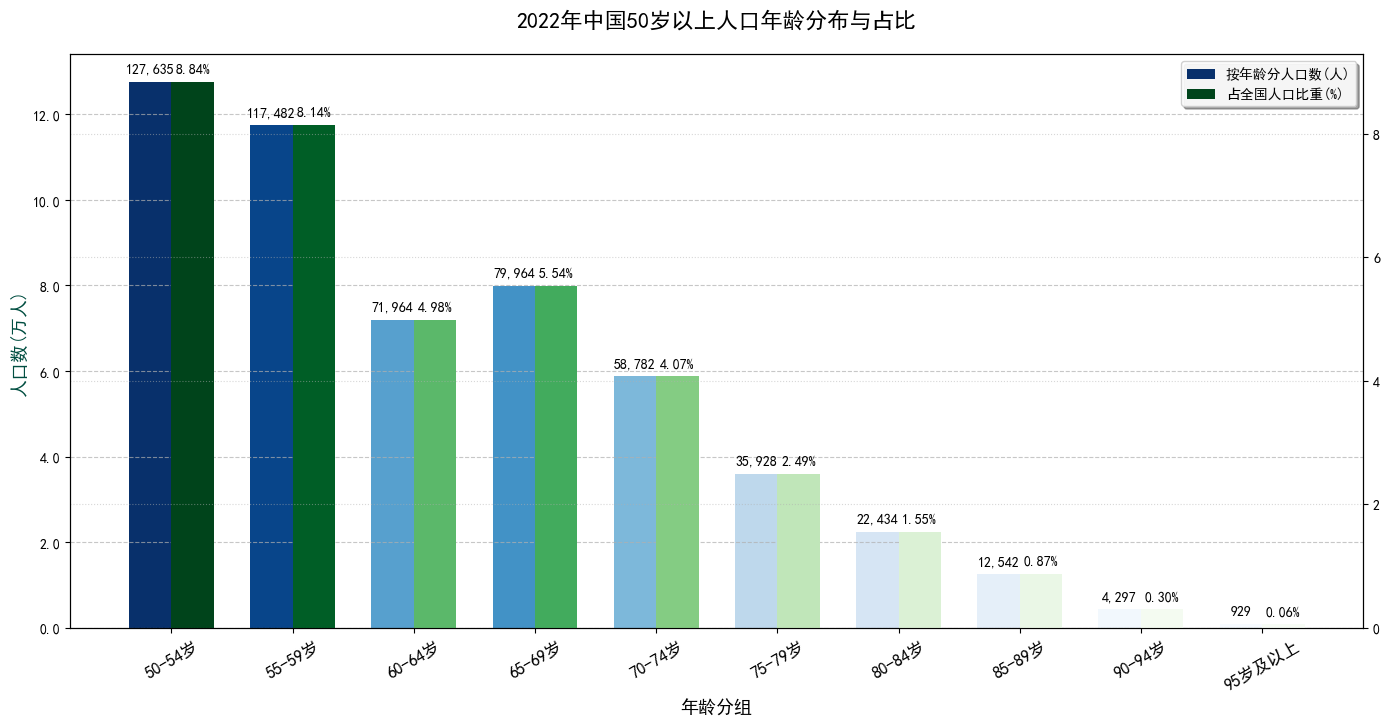

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# 年龄分组
age_groups = [
    "50-54岁", "55-59岁", "60-64岁", "65-69岁", 
    "70-74岁", "75-79岁", "80-84岁", "85-89岁", 
    "90-94岁", "95岁及以上"
]
# 按年龄分人口数（人）
population = [127635, 117482, 71964, 79964, 58782, 35928, 22434, 12542, 4297, 929]
# 占全国人口比重（%）
proportion = [8.84, 8.14, 4.98, 5.54, 4.07, 2.49, 1.55, 0.87, 0.30, 0.06]

x = np.arange(len(age_groups))  # x轴坐标
width = 0.35  # 柱子宽度

# 创建画布和主次坐标轴
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# 绘制人口数柱状图（深蓝色渐变）
cmap1 = plt.cm.Blues
norm1 = plt.Normalize(min(population), max(population))
colors1 = [cmap1(norm1(value)) for value in population]
rects1 = ax1.bar(x - width/2, population, width, label='按年龄分人口数(人)', color=colors1)

# 绘制占比柱状图（深绿色渐变）
cmap2 = plt.cm.Greens
norm2 = plt.Normalize(min(proportion), max(proportion))
colors2 = [cmap2(norm2(value)) for value in proportion]
rects2 = ax2.bar(x + width/2, proportion, width, label='占全国人口比重(%)', color=colors2)

# 设置坐标轴标签和标题
ax1.set_ylabel('人口数(万人)', fontsize=13, color='#004D40')
ax1.set_xlabel('年龄分组', fontsize=13)
ax1.set_title('2022年中国50岁以上人口年龄分布与占比', fontsize=16, pad=20, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(age_groups, rotation=30, ha='center', fontsize=12)

# 设置y轴格式
def thousands_formatter(x, pos):
    return f'{x/10000:.1f}'
ax1.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# 添加网格线
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# 为每个柱子添加数值标签（带千分位分隔符）
def add_labels(rects, ax, is_percent=False):
    for rect in rects:
        height = rect.get_height()
        if is_percent:
            label = f'{height:.2f}%'
        else:
            label = f'{height:,}'
        ax.annotate(label,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 标签距离柱子的垂直距离
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

add_labels(rects1, ax1)
add_labels(rects2, ax2, is_percent=True)

# 美化图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, framealpha=0.9, shadow=True)

# 调整布局
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # 为底部和顶部留出空间
plt.show()

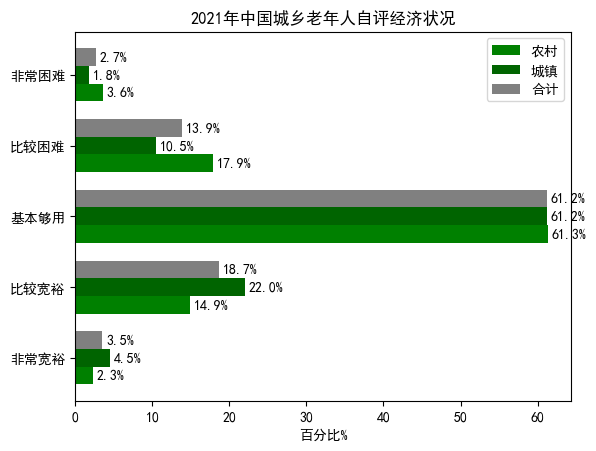

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 类别
categories = ['非常宽裕', '比较宽裕', '基本够用', '比较困难', '非常困难']
# 农村数据
rural = [2.3, 14.9, 61.3, 17.9, 3.6]
# 城镇数据
urban = [4.5, 22.0, 61.2, 10.5, 1.8]
# 合计数据
total = [3.5, 18.7, 61.2, 13.9, 2.7]

x = np.arange(len(categories))  # x 轴位置
width = 0.25  # 每个条形的宽度

fig, ax = plt.subplots()
# 绘制农村、城镇、合计的条形
rects1 = ax.barh(x - width, rural, width, label='农村', color='green')
rects2 = ax.barh(x, urban, width, label='城镇', color='darkgreen')
rects3 = ax.barh(x + width, total, width, label='合计', color='gray')

# 添加标签、标题等
ax.set_yticks(x)
ax.set_yticklabels(categories)
ax.set_xlabel('百分比%')
ax.set_title('2021年中国城乡老年人自评经济状况')
ax.legend()

# 在条形上显示数值
def label_bars(rects):
    for rect in rects:
        length = rect.get_width()
        ax.text(length + 0.5, rect.get_y() + rect.get_height() / 2, f'{length}%', va='center')

label_bars(rects1)
label_bars(rects2)
label_bars(rects3)

plt.show()